This notebook contains code to load the ML6 dataset and peform feature selection using splitted traning and testing dataset.
- Train the model without normalization

In [1]:
import sys
sys.path.insert(0, '../../')

In [2]:
import warnings
warnings.filterwarnings('ignore')

import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score
from sklearn.base import clone
from tqdm import tqdm
from pickle import dump

# load local variables
from src.config import *
from src.load_models import select_model
from src.utils import calculate_r2_score, calculate_per_diff, calculate_combined_r2_and_per_diff, find_adj_score, combine_all_batches, split_batches_back, perform_combat_normalization
from src.utils import calculate_y_LOD, find_score, calculate_r2_score_KFold, calculate_per_diff_KFold
from src.feature_selection import ModelSelection
from src.graph_visualization import feature_selection_tabularize, create_correlation_matrix
from src.outlier_detection import find_outliers_remove

In [3]:
# Load Extracted features dataset
ML6_1 = pd.read_excel('../../dataset/ML6/Day 1 Data/feature_extraction_noise_None.xlsx')
ML6_2 = pd.read_excel('../../dataset/ML6/Day 2 Data/feature_extraction_noise_None.xlsx')

ML6_1['dataset_name'] = '1'
ML6_2['dataset_name'] = '2'

In [4]:
final_dataset = pd.concat([ML6_1, ML6_2], ignore_index=True)
final_dataset['label'] = final_dataset['file'].apply(lambda x: x.split('/')[-1].split('_')[-2].replace('cbz','')).apply(lambda x: int(x))
final_dataset.rename(columns={"PH": 'max(S)', 'signal_std':'std(S)', 'signal_mean':'mean(S)', 'peak area':'area(S)', \
                        'dS_dV_area':'area(dS/dV)', 'dS_dV_max_peak':'max(dS/dV)', 'dS_dV_min_peak':'min(dS/dV)',\
                    'dS_dV_peak_diff':'max(dS/dV) - min(dS/dV)', \
                    'peak V':'V_max(S)', 'dS_dV_max_V':'V_max(dS/dV)', 'dS_dV_min_V':'V_min(dS/dV)',\
        }, inplace = True)

final_dataset = final_dataset[['area(S)', 'max(S)', 'max(dS/dV)', 'min(dS/dV)', 'V_max(S)', 'vcenter', 'V_max(dS/dV)', 'V_min(dS/dV)', 'f1', 'f2', 'file', 'label', 'dataset_name']]

final_dataset

,area(S),max(S),max(dS/dV),min(dS/dV),V_max(S),vcenter,V_max(dS/dV),V_min(dS/dV),f1,f2,file,label,dataset_name
0,1.1035,0.017510,0.3809,-0.5244,1.0509,1.0463,1.032,1.080,0.7072,-16.8102,/Users/sangam/Desktop/Epilepsey/Code/vgramreg/...,4,1
1,2.2940,0.033824,0.6989,-0.8795,1.0582,1.0480,1.036,1.092,1.3894,34.8073,/Users/sangam/Desktop/Epilepsey/Code/vgramreg/...,4,1
2,3.1824,0.051996,1.2167,-1.4382,1.0461,1.0538,1.016,1.072,1.5455,34.8061,/Users/sangam/Desktop/Epilepsey/Code/vgramreg/...,8,1
3,3.1574,0.054249,1.2173,-1.6441,1.0484,1.0491,1.020,1.076,1.0457,-4.3396,/Users/sangam/Desktop/Epilepsey/Code/vgramreg/...,8,1
4,5.5264,0.090447,2.1041,-2.5004,1.0657,1.0712,1.036,1.092,1.2007,25.1452,/Users/sangam/Desktop/Epilepsey/Code/vgramreg/...,16,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
220,8.8870,0.136665,2.9070,-3.4862,1.0594,1.0619,1.028,1.088,1.4306,44.7135,/Users/sangam/Desktop/Epilepsey/Code/vgramreg/...,16,2
221,2.0187,0.031516,0.6744,-0.8230,1.0517,1.0510,1.020,1.076,1.1217,14.4177,/Users/sangam/Desktop/Epilepsey/Code/vgramreg/...,8,2
222,4.3946,0.065702,1.3993,-1.5154,1.0545,1.0570,1.016,1.084,0.9395,35.8728,/Users/sangam/Desktop/Epilepsey/Code/vgramreg/...,12,2
223,1.8908,0.024186,0.5026,-0.6235,1.0352,1.0270,1.016,1.076,0.7506,-3.4662,/Users/sangam/Desktop/Epilepsey/Code/vgramreg/...,4,2


Text(0.5, 1.0, 'Box Plot for ML6 1 and 2 datset')

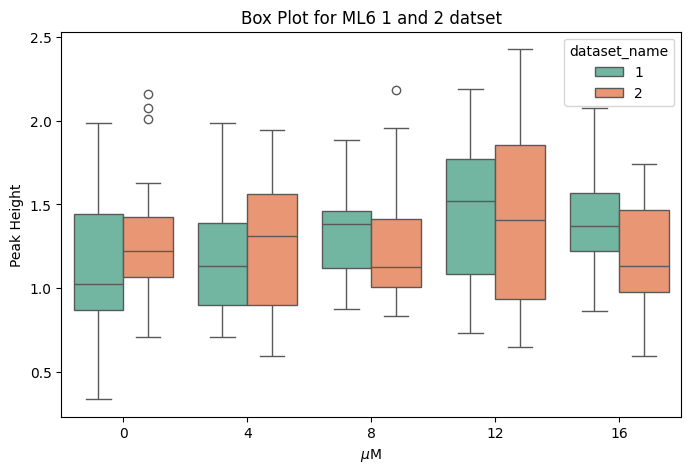

In [5]:
label_order = [0, 4, 8, 12, 16]
plt.figure(figsize=(8, 5))
sns.boxplot(x="label", y="f1", data=final_dataset, hue="dataset_name", palette="Set2", order=label_order)

# Customize the plot
plt.xlabel(r"$\mu $M")
plt.ylabel("Peak Height")
plt.title("Box Plot for ML6 1 and 2 datset")

In [6]:
train, test  = train_test_split(final_dataset, test_size=0.4, shuffle=True, random_state=42, stratify=final_dataset['label'])

# Outlier Removal

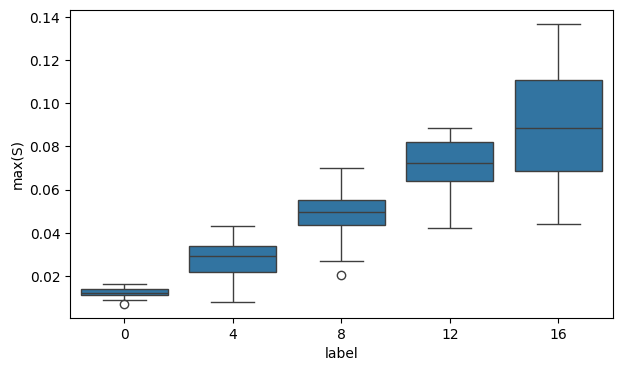

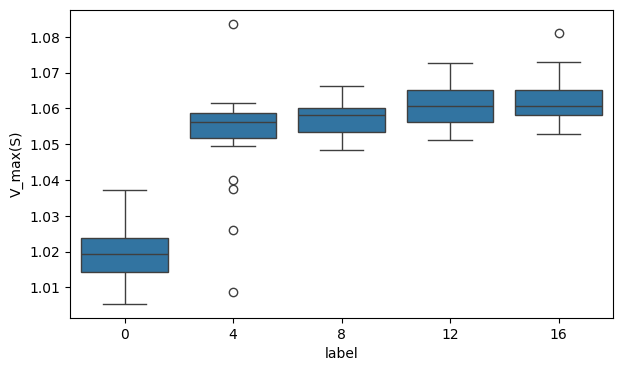

In [7]:
outlier_vis_path ='../../results/Journal_paper/Outlier_Visualization/outlier.png'

# Remove outliers with feature 'max(S)'
X_filtered, outlier_S = find_outliers_remove('max(S)',  train, save_path=outlier_vis_path)

# Remove outliers with feature 'V_max(S)'
X_filtered, outlier_V = find_outliers_remove('V_max(S)', X_filtered, save_path=outlier_vis_path)

In [8]:
all_outliers = [ x for i in outlier_S for x in (outlier_S[i]['above'] + outlier_S[i]['below'])] + \
               [ x for i in outlier_V for x in (outlier_V[i]['above'] + outlier_V[i]['below'])]
all_outliers

['2025_01_25_cbz00_43.txt',
 '2025_01_25_cbz08_23.txt',
 '2025_01_25_cbz04_05.txt',
 '2025_01_25_cbz04_42.txt',
 '2025_01_25_cbz04_17.txt',
 '2025_01_25_cbz04_08.txt',
 '2025_01_25_cbz04_13.txt',
 '2025_01_25_cbz16_43.txt']

In [9]:
outlier_S, outlier_V, len(all_outliers)

({0: {'above': [], 'below': ['2025_01_25_cbz00_43.txt']},
  4: {'above': [], 'below': []},
  8: {'above': [], 'below': ['2025_01_25_cbz08_23.txt']},
  12: {'above': [], 'below': []},
  16: {'above': [], 'below': []}},
 {0: {'above': [], 'below': []},
  4: {'above': ['2025_01_25_cbz04_05.txt'],
   'below': ['2025_01_25_cbz04_42.txt',
    '2025_01_25_cbz04_17.txt',
    '2025_01_25_cbz04_08.txt',
    '2025_01_25_cbz04_13.txt']},
  8: {'above': [], 'below': []},
  12: {'above': [], 'below': []},
  16: {'above': ['2025_01_25_cbz16_43.txt'], 'below': []}},
 8)

In [10]:
# Check if the outliers are in the dataframe or not
assert (not(X_filtered['file'].apply(lambda x: x.split('/')[-1]).isin(all_outliers).any()))

In [11]:
train.shape, X_filtered.shape

((135, 13), (127, 13))

In [12]:
X_train = X_filtered.drop(['label', 'file', 'dataset_name'], axis=1)
y_train = X_filtered['label']
X_test  = test.drop(['label', 'file', 'dataset_name'], axis=1)
y_test  = test['label']

y_LOD     = calculate_y_LOD(X_train, y_train)
print(y_LOD)

# # Remove zero concentration
# indx_gt_zero    = list(y_train[y_train!=0].index)
# X_train         = X_train.loc[indx_gt_zero]
# y_train         = y_train.loc[indx_gt_zero]

# indx_gt_zero    = list(y_test[y_test!=0].index)
# X_test          = X_test.loc[indx_gt_zero]
# y_test          = y_test.loc[indx_gt_zero]

1.0163597575709407


In [ ]:
create_correlation_matrix(X_train, '../../results/Journal_paper/')

In [ ]:
# Perform normalization
from sklearn.preprocessing import StandardScaler
# Standardization
scaler = StandardScaler()

scaler.fit(X_train)
# X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
# X_test  = pd.DataFrame(scaler.transform(X_test),      columns=X_train.columns)

with open('../../weights/Journal_paper/scaler.pkl', 'wb') as f:
    dump(scaler, f)

In [ ]:
# Create a Correlaion heat map
PATH_TO_SAVE = '../results/Journal_paper/'
# create_correlation_matrix(X, PATH_TO_SAVE)

In [13]:
def get_best_score_per_feature_count(feature_scores: dict, only_best=True, higher_better=True):
    best_score_feature_set = []
    feature_scores = [feature_scores[-1]] if only_best else feature_scores

    for ind, feature_set in enumerate(feature_scores):
        feature_comb = list(feature_set.keys())
        scores       = list(feature_set.values())
        best_ind     = np.argmax(scores) if higher_better else np.argmin(scores)

        best_score_feature_set.append((('Prev + ' if ind!=0 else '') + eval(feature_comb[best_ind])[-1], scores[best_ind]))
        

    return best_score_feature_set[-1] if only_best else best_score_feature_set

In [14]:
def plot_model_vs_score(score_df:dict, 
                       metric='',
                       save_path='') -> None:     
    

    ax = score_df.plot(x='Models', y="Scores", kind='bar', legend=False)
    plt.legend()
    for i, p in enumerate(ax.patches):
        ax.annotate(str(round(p.get_height(), 4)), (p.get_x() + p.get_width() / 2., 0.3 * p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points',  rotation='vertical', fontsize=10, )
    
    plt.xticks(rotation=45, ha='right')
    plt.xlabel('Feature set')
    plt.ylabel(metric)
    plt.legend().set_visible(False)
    if save_path!='':
        plt.savefig(f'{save_path}', dpi=300, bbox_inches='tight')
    

In [ ]:
# List of models
models = ['RF']
root_path = '../results/Journal_paper'


# Calcualte y_LOD
kf        = KFold(n_splits=5, shuffle=True, random_state=42)
add_alpha = False

find_class_stratified_score = True

r2_score_val,  per_diff_val  = {'Models':[], 'Scores':[]}, {'Models':[], 'Scores':[]}
r2_score_test, per_diff_test = {'Models':[], 'Scores':[]}, {'Models':[], 'Scores':[]}

r2_score_class_stratified_test = {'Models':[], '0':[], '5':[], '8':[], '10':[], '15':[], '16':[]} if add_alpha else {'Models':[], '0':[], '8':[], '16':[]}
per_diff_class_stratified_test = {'Models':[], '0':[], '5':[], '8':[], '10':[], '15':[], '16':[]} if add_alpha else {'Models':[], '0':[], '8':[], '16':[]}

metric  = 'combine'
higher_better=False if metric=='per_diff' else True

cross_feature_score = {'Models':[], 'Feature_Selected_ON':[], 'Feature_set':[], 'Other_Metric_Score':[]}

from time import time
for model_name in tqdm(models):

    starttime         = time()
    model             = ModelSelection(model_name, X_train, y_train)
    selected_features, best_params = model.find_best_features(kf, 
                                                              metric=metric, 
                                                              use_adjusted_r2=True, 
                                                              tune_hyperparameter=True)
    
    df                     = feature_selection_tabularize(selected_features)
    df['best_params_list'] = best_params + [{}]*(len(df)- len(best_params))

    # Store the feature selection step in a Excel sheet
    feature_selected_excel_save_path = f'{root_path}/Feature_selection/{model_name}_feature_selection_{metric}.xlsx'
    os.makedirs(os.path.dirname(feature_selected_excel_save_path), exist_ok=True)
    df.to_excel(feature_selected_excel_save_path)
    
    best_score_feature_set = get_best_score_per_feature_count(selected_features, only_best=False, higher_better=higher_better)

    save_path = f'{root_path}/Comparison_barchart/{model_name}_{metric}.png'
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    best_score_df = pd.DataFrame(best_score_feature_set, columns=["Models", "Scores"])
    plot_model_vs_score(best_score_df, metric, save_path)

    # Train the model and calculate different metric scores.
    selected_feature_set = [(i[0].split('+')[-1]).strip() for i in best_score_feature_set]

    cross_feature_score['Models'].append(model_name)
    cross_feature_score['Feature_Selected_ON'].append(f'{metric} : {round(best_score_feature_set[-1][-1], 4)}')
    cross_feature_score['Feature_set'].append(selected_feature_set)

    temp_holder = []
    for test_metric in ['r2', 'combine', 'per_diff']:
        if (metric != test_metric):
            if model_name != 'Linear':
                model.model.set_params(**best_params[-1]) # Set the best hyper parameter
                
            score = model.find_score_KFold(kf, selected_feature_set, test_metric, use_adjusted_r2=True)
            temp_holder.append(f'{test_metric}: {round(score, 4)}')

    cross_feature_score['Other_Metric_Score'].append(' | '.join(temp_holder))

    print(f"Model name: {model_name} | Run Time: {time() - starttime}")

cross_metric_evaluation_results_path = os.path.join(root_path, f'Cross_Feature_Set/feature_selected_on_{metric}.xlsx')
os.makedirs(os.path.dirname(cross_metric_evaluation_results_path), exist_ok=True)
cross_feature_set_df = pd.DataFrame(cross_feature_score)
cross_feature_set_df.to_excel(cross_metric_evaluation_results_path)

In [ ]:
y_LOD     = calculate_y_LOD(X_train, y_train)
y_LOD

In [15]:
def calculate_per_diff_KFold(model, 
                       X:pd.DataFrame, 
                       y:pd.Series, 
                       X_test:pd.DataFrame, 
                       y_test:pd.Series,
                       y_LOD:float,
                       kf:KFold
                       ) -> np.float64:
    """
        This function calculates the % difference for KFold.
    """
     
    per_diff_val_all  = []
    per_diff_test_all = []
    
    for train_index, test_index in kf.split(X):
        model_ = clone(model)
    
        # Split the data into training and testing sets
        X_train, X_val = X.iloc[train_index], X.iloc[test_index]
        y_train, y_val = y.to_numpy()[train_index], y.to_numpy()[test_index]
    
        model_.fit(X_train, y_train)
        y_pred_val  = model_.predict(X_val)
        y_pred_test = model_.predict(X_test)

        per_error_val  = calculate_per_diff(y_val,  y_pred_val, y_LOD)
        per_error_test = calculate_per_diff(y_test, y_pred_test, y_LOD)
        
        per_diff_val_all.append(per_error_val)
        per_diff_test_all.append(per_error_test)

    return np.array(per_diff_val_all).mean(), np.array(per_diff_test_all).mean()

In [16]:

# Without V_outlier removal
features_list= {'KNN':    ['min(dS/dV)', 'max(S)'], 
                'Linear': ['min(dS/dV)', 'V_max(S)', 'f2', 'f1', 'V_max(dS/dV)'], 
                'RF':     ['min(dS/dV)', 'f2', 'area(S)', 'V_max(dS/dV)'], 
                'SVM':    ['min(dS/dV)', 'area(S)', 'vcenter', 'V_max(dS/dV)', 'max(dS/dV)'], 
                'GP':     ['min(dS/dV)', 'area(S)', 'V_max(dS/dV)', 'max(dS/dV)'],
                'xgboost': ['min(dS/dV)', 'area(S)', 'V_max(dS/dV)']}

param_list =  {'KNN': {'n_neighbors': 12, 'weights': 'distance', 'metric': 'manhattan'},
               'Linear': {},
               'RF': {'n_estimators': 40,  'max_depth': 5,    'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 2},
               'SVM': {'C': 250, 'gamma': 0.1, 'kernel': 'rbf'},
               'GP': {'kernel': 1**2 * Matern(length_scale=1, nu=1.5), 'alpha': 2.5},
               'xgboost': {'n_estimators': 100, 'max_depth': 10, 'gamma': 1, 'reg_alpha': 1, 'reg_lambda': 1}}

# With V_outlier removal
# features_list= {'KNN':    ['min(dS/dV)', 'area(S)', 'V_max(S)', 'V_min(dS/dV)'], 
#                 'Linear': ['min(dS/dV)', 'f2', 'max(dS/dV)', 'V_max(dS/dV)'], 
#                 'RF':     ['min(dS/dV)', 'f2', 'area(S)', 'vcenter'], 
#                 'SVM':    ['min(dS/dV)', 'V_max(S)'], 
#                 'GP':     ['min(dS/dV)', 'area(S)'],
#                 'xgboost': ['min(dS/dV)', 'area(S)', 'V_max(dS/dV)']}

# param_list =  {'KNN': {'n_neighbors': 3, 'weights': 'uniform', 'metric': 'manhattan'},
#                'Linear': {},
#                'RF': {'n_estimators': 80, 'max_depth': 10, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 5},
#                'SVM': {'C': 300.0, 'gamma': 1.0, 'kernel': 'rbf'},
#                'GP': {'kernel': 1**2 * Matern(length_scale=1.5, nu=1.5), 'alpha': 3.0},
#                'xgboost': {'n_estimators': 100, 'max_depth': 10, 'gamma': 1, 'reg_alpha': 1, 'reg_lambda': 1}}

# Validation score

In [ ]:
models    = ['KNN', 'RF', 'SVM', 'Linear', 'GP']
root_path   = '../results/Journal_paper/without_zero'
weight_path = '../weights/Journal_paper/without_zero'
os.makedirs(weight_path, exist_ok=True)

y_LOD     = 1.0163597575709407
kf        = KFold(n_splits=5, shuffle=True, random_state=42)

for metric in ['per_diff']:
    train_val_score           = {'Models':[], 'Scores':[]}
    test_score                = {'Models':[], 'Scores':[]}
    test_score_all_train      = {'Models':[], 'Scores':[]}
    
    for model_name in models:
        model = select_model(model_name)
        model.set_params(**param_list[model_name])
        selected_feature_set = features_list[model_name]
        
        # Calculate the test score on the given performance metrics
        train_val_score['Models'].append(model_name)
        test_score['Models'].append(model_name)
        test_score_all_train['Models'].append(model_name)
        
        if metric == 'r2':
            score           = calculate_r2_score_KFold(model, X_train[selected_feature_set], y_train, kf, use_adjusted_r2=False)
        else:
            score_val, score_test = calculate_per_diff_KFold(model, X_train[selected_feature_set], y_train, X_test[selected_feature_set], y_test, y_LOD, kf)

        # model_temp = clone(model)
        model.set_params(**param_list[model_name])
        model.fit(X_train[selected_feature_set], y_train)
        y_pred = model.predict(X_test[selected_feature_set])
        
        score = find_score(y_test, y_pred, y_LOD=y_LOD, metric=metric, use_adjusted_r2=False, feature_len=len(selected_feature_set))
        
        train_val_score['Scores'].append(score_val)
        test_score['Scores'].append(score_test)
        test_score_all_train['Scores'].append(score)
    
    save_path = os.path.join(root_path, f'Train_Validation_Results/test_results_{metric}.png')
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    df_train_score = pd.DataFrame(train_val_score)
    df_train_score = df_train_score.sort_values(by='Scores')
    plot_model_vs_score(df_train_score, metric, save_path)
    plt.show()

    save_path = os.path.join(root_path, f'Test_Results/test_results_train_val_{metric}.png')
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    df_test_score = pd.DataFrame(test_score)
    df_test_score = df_test_score.sort_values(by='Scores')
    plot_model_vs_score(df_test_score, metric, save_path)
    plt.show()

    save_path = os.path.join(root_path, f'Test_Results/test_results_full_train_{metric}.png')
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    df_test_train_full_score = pd.DataFrame(test_score_all_train)
    df_test_train_full_score = df_test_train_full_score.sort_values(by='Scores')
    plot_model_vs_score(df_test_train_full_score, metric, save_path)
    plt.show()


# Prediction models on testing resutls



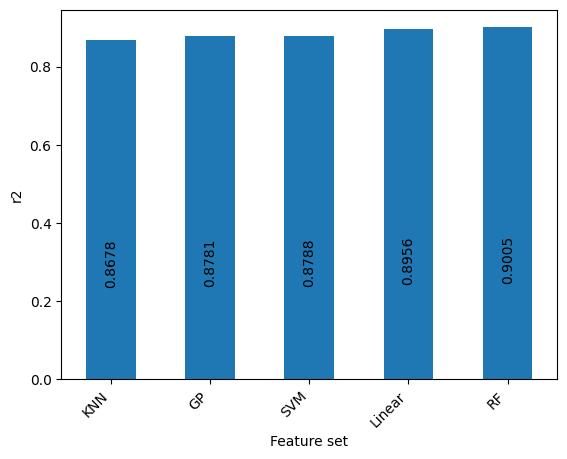

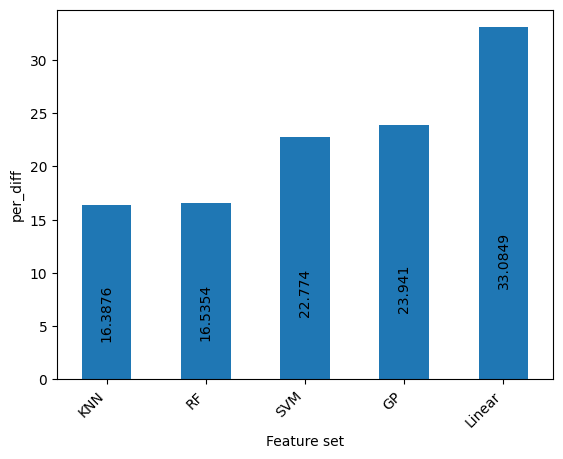

In [17]:
models    = ['KNN', 'RF', 'SVM', 'Linear', 'GP']
root_path   = '../../results/Journal_paper'
weight_path = '../../weights/Journal_paper'
os.makedirs(weight_path, exist_ok=True)

y_LOD       = 1.0163597575709407

for metric in ['r2', 'per_diff']:
    test_score = {'Models':[], 'Scores':[]}
    for model_name in models:
        model = select_model(model_name)
        model.set_params(**param_list[model_name])
        selected_feature_set = features_list[model_name]
        
        # Calculate the test score on the given performance metrics
        test_score['Models'].append(model_name)
        model.fit(X_train[selected_feature_set], y_train)

        # Save Model weights
        with open(f'{weight_path}/{model_name}.pkl', 'wb') as f:
            dump(model, f)
        
        y_pred = model.predict(X_test[selected_feature_set])
        score  = find_score(y_test, y_pred, y_LOD=y_LOD, metric=metric, use_adjusted_r2=False, feature_len=len(selected_feature_set))
        test_score['Scores'].append(score)
    
    save_path = os.path.join(root_path, f'Test_Results/test_results_{metric}.png')
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    df_test_score = pd.DataFrame(test_score)
    df_test_score = df_test_score.sort_values(by='Scores')
    plot_model_vs_score(df_test_score, metric, save_path)
    plt.show()

# Random Forest Testing in Details


In [ ]:
model_name = 'RF'
y_LOD      = 0.887719676355663
model      = select_model(model_name)
model.set_params(**param_list[model_name])
selected_feature_set = features_list[model_name]

# Calculate the test score on the given performance metrics
model.fit(X_train[selected_feature_set], y_train)

y_pred = model.predict(X_test[selected_feature_set])

output_df = pd.DataFrame({'y_pred':y_pred, 'y_test':y_test})

# score  = find_score(y_test, y_pred, y_LOD=y_LOD, metric=metric, use_adjusted_r2=False, feature_len=len(selected_feature_set))
# test_score['Scores'].append(score)

In [ ]:
output_df.shape

In [ ]:
def compute_percent_error_per_file(x):
    y_pred, y_test =  x['y_pred'], x['y_test']
    y_pred         = max(y_pred, 0.0)

    # Only for non zero concentration
    if y_test != 0:
        per_error = abs(y_test - y_pred) * (2 / (y_test + y_pred))
    else:   
        per_error     = abs(y_test - y_pred) *  (2 / (y_LOD + y_pred))

    assert not(np.isnan(per_error))

    per_error         = per_error * 100

    return per_error

In [ ]:
output_df['per_error'] = output_df.apply(compute_percent_error_per_file, axis=1)
final = output_df.join(test[['file']], how='inner')

In [ ]:
final['file'] = final['file'].apply(lambda x: x.split('/')[-1])
sorted_final_result = final.sort_values('per_error', ascending=False)

In [ ]:
sorted_final_result.to_excel('../results/per_row_per_error.xlsx')

In [ ]:
import sys
sys.path.insert(0, '../')

In [ ]:
import pandas as pd
import numpy as np
from src.load_models import select_model
from typing import Tuple
from src.utils import calculate_r2_score_KFold, calculate_per_diff_KFold, calculate_combined_r2_and_per_diff_KFold

from src.load_models import select_model
from src.utils import calculate_y_LOD

from sklearn.model_selection import KFold

In [ ]:
class testing:
    def __init__(self, 
                 model_name:str, 
                 X_train:pd.DataFrame, 
                 y_train:pd.Series):
        
        self.X_train, self.y_train = X_train, y_train
        self.model = select_model(model_name)
        self.model_name = model_name
        self.all_feature_scores = []
    
        self.y_LOD = calculate_y_LOD(self.X_train, self.y_train) 
        
    def list_all_parameters(self, params_dict:dict) -> pd.DataFrame:
        all_keys     = list(params_dict.keys())
        all_params   = pd.DataFrame(params_dict[all_keys[0]], columns=[all_keys[0]])

        for key in all_keys[1:]:
            all_params = all_params.merge(pd.DataFrame(params_dict[key], columns=[key]), how='cross')

        return all_params
    
    def calculate_score_hyperparameter(self, 
                                       params:dict, 
                                       metric:str, 
                                       features:list, 
                                       kf:KFold, 
                                       use_adjusted_r2:bool) -> np.float64:
        
        # Assign new parameters to the base model
        params_dict = params.to_dict()
        self.model.set_params(**params_dict)

        # Calcualte metric
        if 'r2'in metric:
            return calculate_r2_score_KFold(self.model, self.X_train[features], self.y_train, kf, use_adjusted_r2=use_adjusted_r2)

        elif metric=='per_diff':  
            return calculate_per_diff_KFold(self.model, self.X_train[features], self.y_train, self.y_LOD, kf)

        else:
            return calculate_combined_r2_and_per_diff_KFold(self.model, self.X_train[features], self.y_train, kf, self.y_LOD, use_adjusted_r2=use_adjusted_r2)


        

    def find_best_score_hyperparameter_KFold(self, 
                                  kf:KFold, 
                                  testing_feature:list, 
                                  metric:str, 
                                  use_adjusted_r2:bool) -> Tuple:
        
        all_params_df = self.list_all_parameters(param_grids[self.model_name])
        all_params_df['score'] = all_params_df.apply(self.calculate_score_hyperparameter, axis=1, args=(metric, testing_feature,kf,use_adjusted_r2))

        if metric=='per_diff': best_features = all_params_df.loc[[all_params_df['score'].idxmin()]]
        else: best_features = all_params_df.loc[[all_params_df['score'].idxmax()]]
       
        print(best_features)
        best_score    = best_features['score'].to_list()[0]
        return best_features.drop('score', axis=1).to_dict(orient='records')[0], best_score


In [ ]:
param_grids = {'SVM':{
                    'C': [1, 10, 15, 20, 100],
                    'gamma': [0.0001, 0.0005, 0.001, 0.005, 0.01],
                    'kernel': ['rbf']},
              
              'RF': {
                    'n_estimators': [80, 100, 120],
                    'max_depth': [5, 10, 15],
                    'min_samples_split': [6, 8, 10, 16,20],
                    'min_samples_leaf': [2,4,6] 
                     },
              
              'KNN': {
                        'n_neighbors': [3, 5, 6, 7, 8, 9],
                        'weights': ['uniform', 'distance'],
                        'metric': ['euclidean', 'manhattan']
                    },
              
              'GP': {'kernel': [1.0 * RBF(length_scale=1.0), 
                                1.0 * RBF(length_scale=0.5), 
                                1.0 * RBF(length_scale=1.5), 
                                1.0 * RBF(length_scale=2.0),
                                1.0 * RBF(length_scale=2.5),
                                1.0 * Matern(length_scale=1.0, nu=1.5)],
                     'alpha': [0.001, 0.01, 0.1, 1, 1.5, 2, 2.5]},
               'Ridge': {'alpha': [0.0001, 0.0005, 0.001, 0.003, 0.005, 0.01, 0.1, 1.0]},
               'Lasso': {'alpha': [0.00001, 0.00003, 0.00005, 0.0001, 0.0003, 0.0005, 0.001]}
              }

In [ ]:
model       = testing('RF', X_train, y_train)
feature_set = ['area(S)', 'max(S)', 'max(dS/dV)', 'min(dS/dV)', 'V_max(S)', 'vcenter', 'V_max(dS/dV)', 'V_min(dS/dV)', 'f1', 'f2']

kf        = KFold(n_splits=5, shuffle=True, random_state=42)
best_model, score = model.find_best_score_hyperparameter_KFold(kf, feature_set, 'per_diff', use_adjusted_r2=True,)

In [ ]:
best_model, score

In [ ]:
model = select_model('KNN')
kf        = KFold(n_splits=5, shuffle=True, random_state=42)

feature_set = ['min(dS/dV)']

params = {'n_neighbors':8, 
          'weights':'uniform', 
          'metric':'euclidean'}

model.set_params(**params)
print(model.get_params())

print(calculate_r2_score_KFold(model, X_train[feature_set], y_train, kf, use_adjusted_r2=True))

print(calculate_per_diff_KFold(model, X_train[feature_set], y_train, calculate_y_LOD(X_train, y_train), kf))

In [ ]:
best_params